In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle


Data collecting and processing

In [9]:
df = pd.read_csv('/content/Rainfall.csv')



In [10]:
df.shape

(366, 12)

In [11]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [12]:
df['day'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [14]:
df.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [15]:
#remove extra space for all columns
df.columns = df.columns.str.strip()



In [16]:
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [17]:
# drop day column
df.drop(columns=['day'], inplace=True)

In [18]:
df.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [19]:
# checking missing value
df[df.isnull().any(axis=1)]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
160,1005.7,31.7,28.2,26.6,25.7,86,79,yes,6.5,NaN,NaN


In [20]:
# handle missing value
df['winddirection'] = df['winddirection'].fillna(df['winddirection'].mode()[0])
df['windspeed'] = df['windspeed'].fillna(df['windspeed'].median())

In [21]:
df.iloc[160]

,160
pressure,1005.7
maxtemp,31.7
temparature,28.2
mintemp,26.6
dewpoint,25.7
humidity,86
cloud,79
rainfall,yes
sunshine,6.5
winddirection,20.0


In [22]:
# changing rain yes to 1 and no to 0
df['rainfall'] = df['rainfall'].replace('yes',1)
df['rainfall'] = df['rainfall'].replace('no',0)


/tmp/ipykernel_1579/3426433211.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rainfall'] = df['rainfall'].replace('no',0)


In [23]:
df.sample(5)

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
284,1018.0,22.1,20.5,18.5,16.6,78,88,1,0.0,20.0,38.3
245,1010.9,27.7,25.8,24.5,24.8,94,88,1,0.0,110.0,16.5
139,1009.9,28.1,25.5,24.0,22.5,84,85,1,3.5,70.0,26.4
71,1017.7,14.5,13.6,12.7,11.4,87,100,1,0.0,50.0,36.0
129,1010.1,30.6,28.7,26.9,25.0,81,69,0,3.9,170.0,16.3


EDA

In [24]:
sns.set(style='whitegrid')

In [25]:
df.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


In [26]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

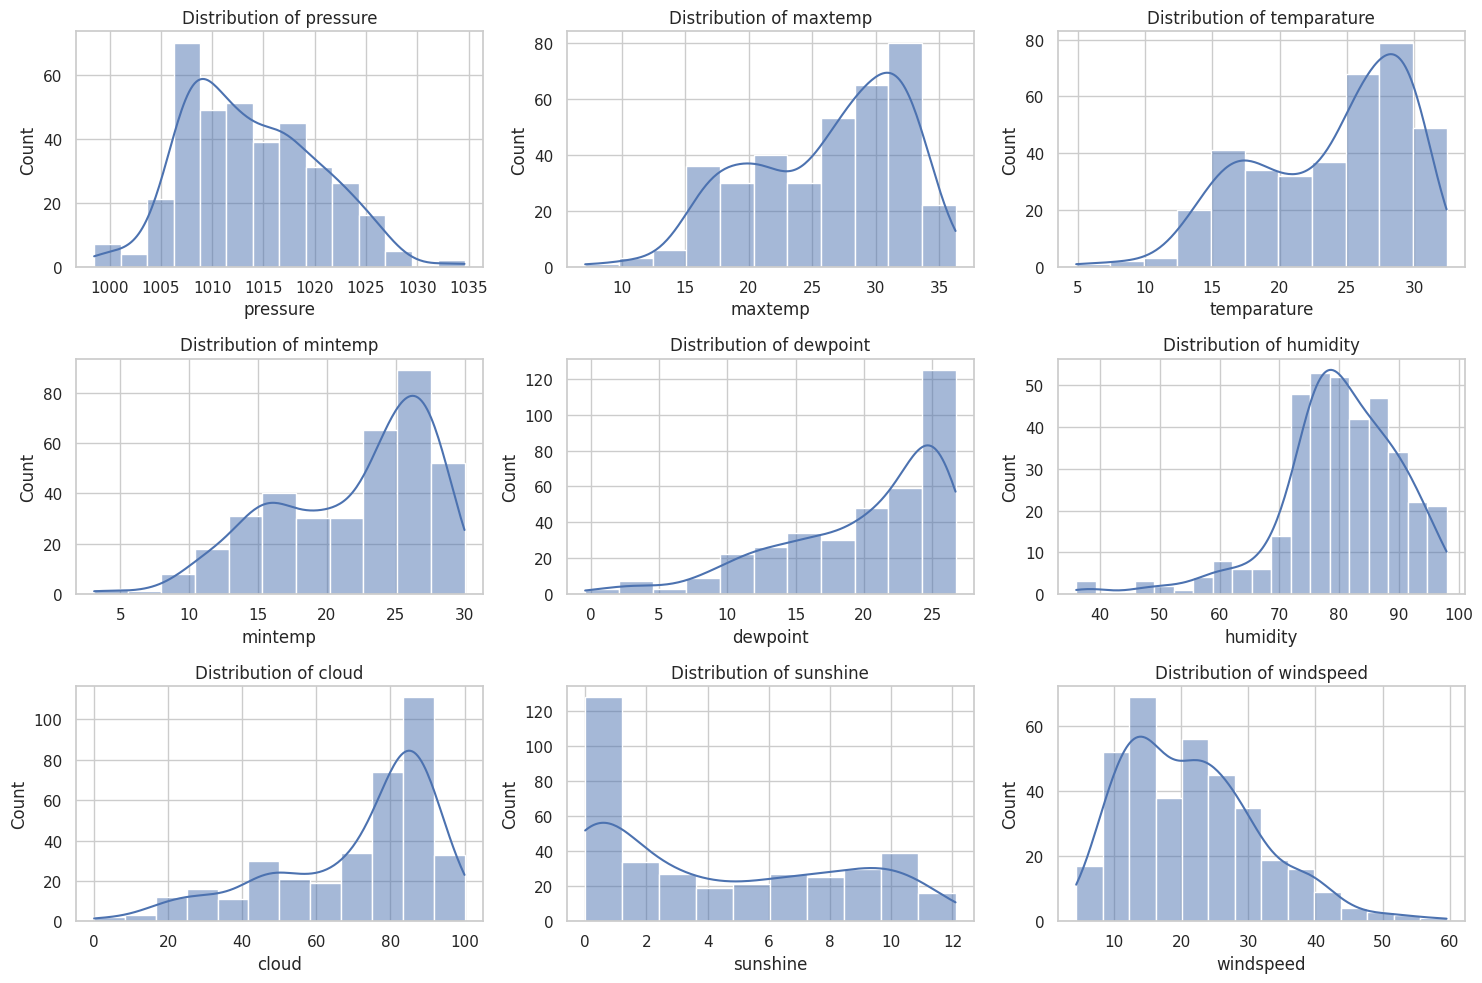

In [27]:
plt.figure(figsize=(15,10))
for i, col in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine',  'windspeed'],1):
  plt.subplot(3,3,i)
  sns.histplot(df[col],kde=True)
  plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

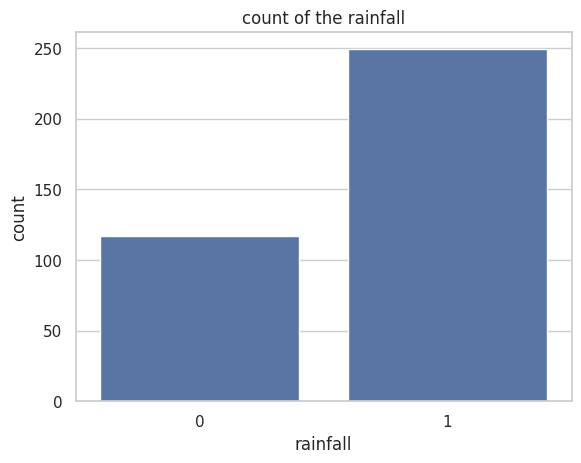

In [28]:
sns.countplot(x='rainfall', data=df)
plt.title("count of the rainfall")
plt.show()

In [29]:
df['rainfall'].groupby(df['rainfall']).count()

,rainfall
rainfall,
0,117
1,249


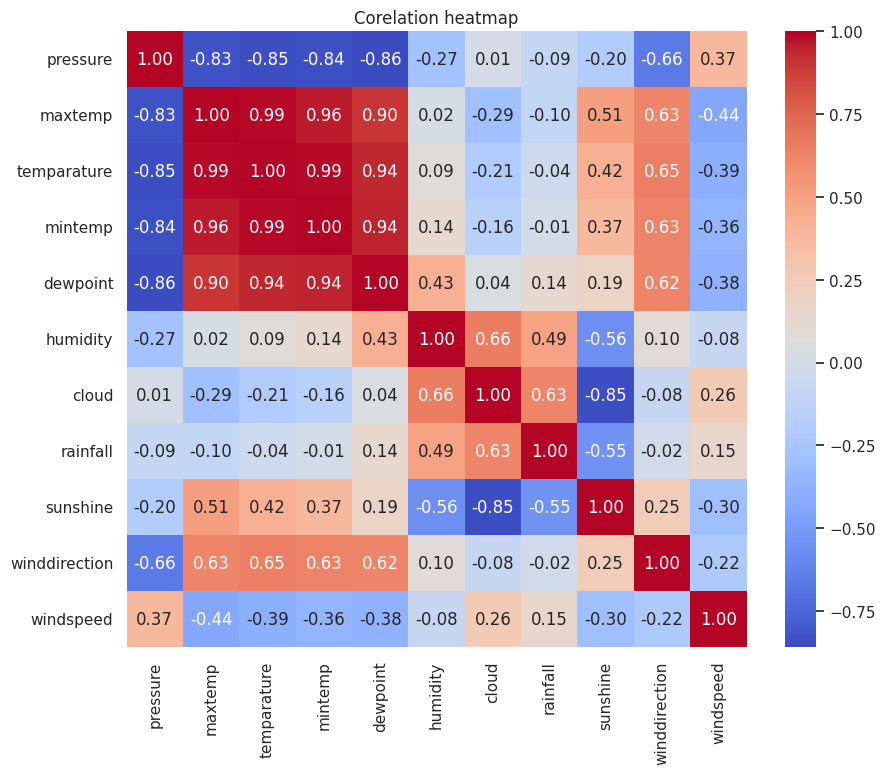

In [30]:
# coreletion matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm", fmt='.2f')
plt.title('Corelation heatmap')
plt.show()



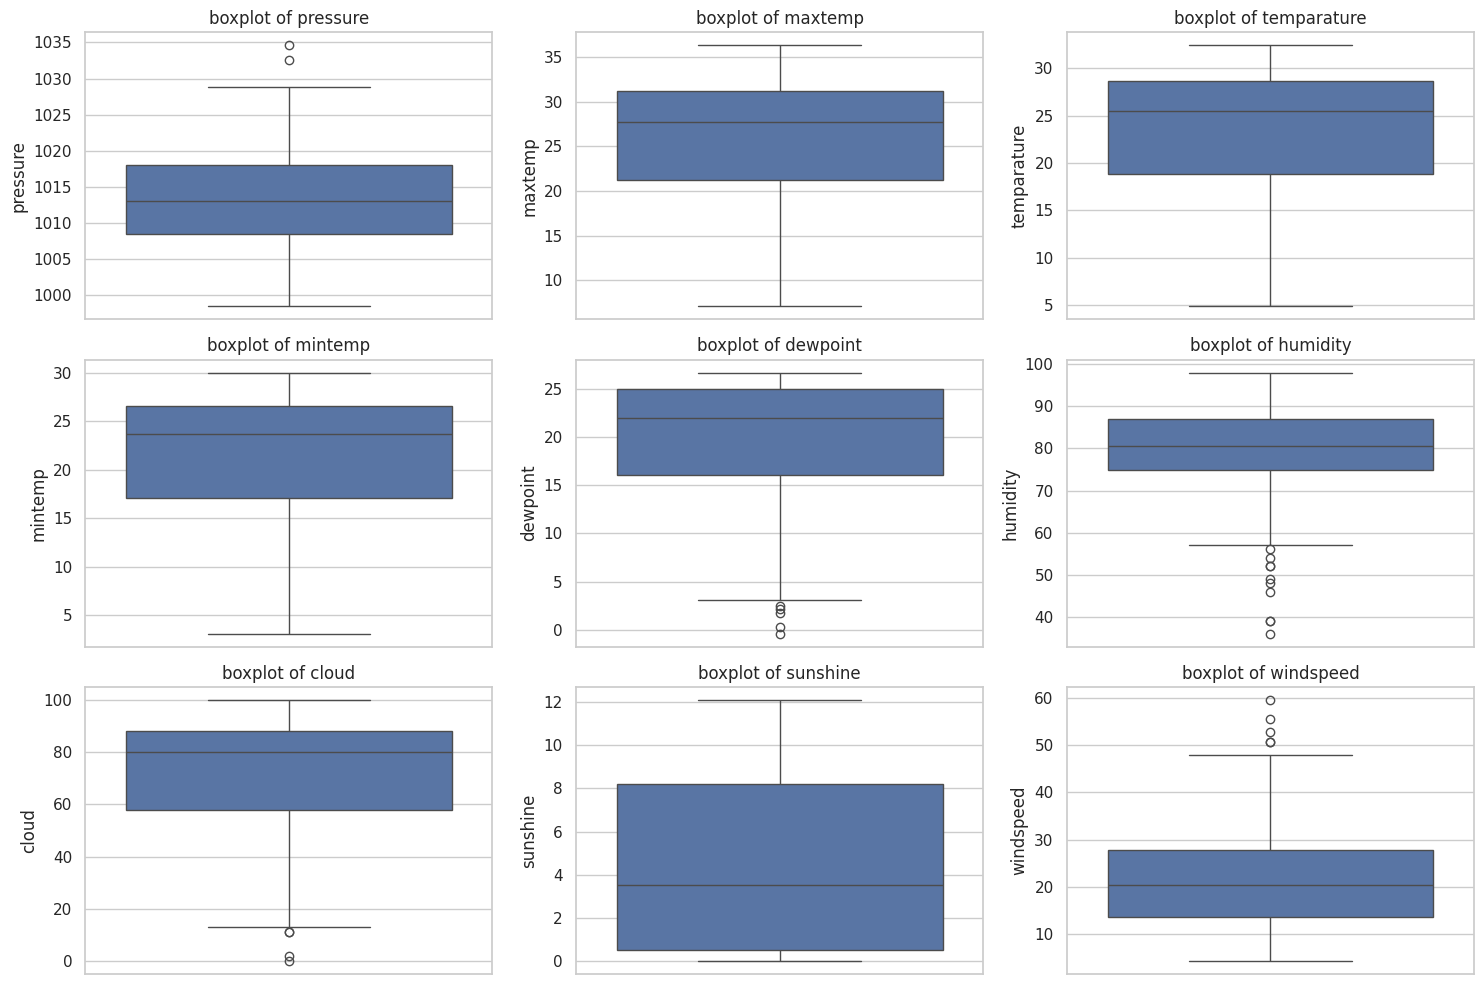

In [31]:
plt.figure(figsize=(15,10))
for i, col in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine',  'windspeed'],1):
  plt.subplot(3,3,i)
  sns.boxplot(df[col])
  plt.title(f"boxplot of {col}")

plt.tight_layout()
plt.show()

data preprocessing


In [32]:
# drop highly corelated columns
df = df.drop(columns=['maxtemp', 'temparature', 'mintemp'])

<Axes: >

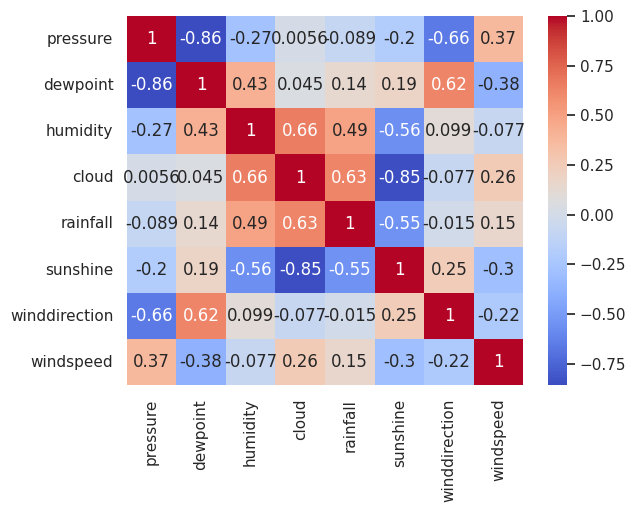

In [33]:
sns.heatmap(data=df.corr(),annot=True , cmap='coolwarm')

In [34]:
df['rainfall'].value_counts()

,count
rainfall,
1,249
0,117


In [35]:
#seperate majority and minority class
df_majority = df[df['rainfall']==1]
df_minority = df[df['rainfall']==0]

In [36]:
df_minority.shape

(117, 8)

In [37]:
# downsample the majorit class
df_majority_downsample = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)

In [38]:
df_majority_downsample.shape

(117, 8)

In [39]:
df_downsampled = pd.concat([df_majority_downsample, df_minority])

In [40]:
df_downsampled.shape

(234, 8)

In [41]:
df_downsampled['rainfall'].value_counts()

,count
rainfall,
1,117
0,117


In [42]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5
89,1018.3,16.3,79,89,1,2.4,40.0,14.8
157,1008.8,24.7,91,80,1,2.2,20.0,11.2


In [43]:
# shuffle the donwsampled data to final df
df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

In [44]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,1007.6,24.8,85,84,1,1.8,70.0,34.8
4,1021.2,8.4,66,18,0,10.1,20.0,24.4


In [45]:
x = df_downsampled.drop(columns=['rainfall'])
y = df_downsampled['rainfall']

In [46]:
# splitting the data into training and testing set
x_train, x_test , y_train , y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [111]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10,20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [112]:
rf = RandomForestClassifier( random_state=42)



In [113]:

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [114]:
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [115]:
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best score: 0.8125895125895127


In [120]:
y_pred = grid.best_estimator_.predict(x_test)

In [121]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7446808510638298
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.67      0.73        24
           1       0.70      0.83      0.76        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47

Confusion Matrix:
 [[16  8]
 [ 4 19]]


In [122]:
def predict_rainfall(pressure, dewpoint, humidity, cloud, sunshine, winddirection, windspeed):

    input_data = pd.DataFrame([[pressure, dewpoint, humidity, cloud, sunshine, winddirection, windspeed]],
                              columns=x_train.columns)

    prediction = grid.best_estimator_.predict(input_data)

    if prediction[0] == 1:
        return "It will rain"
    else:
        return "It will not rain"



sample_pressure = 1010.0
sample_dewpoint = 20.0
sample_humidity = 85
sample_cloud = 70
sample_sunshine = 2.5
sample_winddirection = 90.0
sample_windspeed = 25.0

prediction_result = predict_rainfall(
    pressure=sample_pressure,
    dewpoint=sample_dewpoint,
    humidity=sample_humidity,
    cloud=sample_cloud,
    sunshine=sample_sunshine,
    winddirection=sample_winddirection,
    windspeed=sample_windspeed
)

print(f"Based on the provided data : {prediction_result}")

Based on the provided data : It will rain


In [125]:
#save model and features name to a pickle file
model_data = {"model": best_rf_model, "features_names": x.columns.tolist() }
with open('model.pkl', 'wb') as file:
    pickle.dump(model_data, file)